## Bijdrage Raoul Buffels — DeepLearningTeam10

Deze Citi Bike-uitwerking is aangeleverd als de bijdrage van **Raoul Buffels**. Teamleden: Jorre Van Dyck, Milan Wouters, Raoul Buffels en Andrew Noeyens. De concrete menselijke taakverdeling moet het team zelf aanvullen. **AI-gebruik:** Codex hielp met implementatie, uitleg, tests, uitvoering en verpakking.

De codecellen zijn uitgevoerd in de oorspronkelijke lokale `Citybike_full`-omgeving op 9 oktober 2026. Deze export behoudt die echte uitvoer; alleen deze Markdown-cel is toegevoegd. Lokale paden, timings en fingerprints in de rapporten beschrijven de oorspronkelijke uitvoering. Start voor heruitvoering vanuit `SolutionRaoul/Citybike` of de map `notebooks` met de bijbehorende Python 3.11-omgeving. AWS is een afzonderlijke latere taak.

# NYC Citi Bike Analysis & Predictive Modeling

**OBTAIN → SCRUB → EXPLORE → MODEL → INTERPRET → DEPLOY**

Teamleden en echte bijdragen: **door het team in te vullen**. Codex hielp met implementatie, tests en uitvoering; controleer het opleidingsbeleid en verdedig iedere stap zelf.

## 0. Projectdoel

Wat vertellen geregistreerde ritten over het systeem, en welk nuttig doel kunnen we voorspellen? Het voorspeldoel wordt pas na ontwikkelings-EDA en statistische onderzoek gekozen. NYC en Jersey City blijven gescheiden. Juli–augustus 2026 is uitsluitend eindtest; AWS-training volgt later.

## 1. Imports & configuratie

De CLI voert de zware stappen uit. Dit notebook toont de werkelijk berekende resultaten. Ontbrekende rapporten zijn fouten, geen verzonnen vervanging. Zie README voor een volledige herbouw.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Markdown
locations = [Path.cwd(), Path.cwd().parent, Path.cwd() / 'Citybike_full']
ROOT = next((p for p in locations if (p / 'citibike').exists()), None)
if ROOT is None: raise RuntimeError('Start dit notebook vanuit Citybike_full of notebooks.')
sys.path.insert(0, str(ROOT))
from citibike.config import REPORTS, DATA, MODELS
from citibike.datasets import manifest
from citibike.plots import show
def report(name):
    return json.loads((REPORTS / name).read_text(encoding='utf-8'))
def table(name):
    display(pd.read_csv(REPORTS / name, dtype={'start_station_id':'string','end_station_id':'string','station_id':'string'}))


## 2. Data discovery — OBTAIN

De code inventariseert bronnen en CSV-leden, inclusief maand-ZIPs in jaararchieven. SHA-256 identificeert de bronnen. Technische eindtestgegevens zoals schema en rij-aantallen mogen hier worden getoond; eindtestpatronen niet.

In [2]:
m = manifest()
display(pd.DataFrame([{'bronbestanden':m['source_count'],'bron_GiB':m['source_bytes']/2**30,'ruwe_rijen':m['raw_rows'],'bewaarde_rijen':m['retained_rows'],'laatste_run_minuten_inclusief_cachecontrole':m['processing_seconds']/60}]))
display(pd.DataFrame(m['coverage']).T)

,bronbestanden,bron_GiB,ruwe_rijen,bewaarde_rijen,laatste_run_minuten_inclusief_cachecontrole
0,175,29.604076,355199439,330714664,5.084499


,first_month,last_month,missing_months
NYC,2013-06,2026-08,[]
JC,2015-09,2026-08,[]


## 3. Schemaonderzoek

Historische headers verschillen in namen, hoofdletters en inhoud. We mappen start/stop, gebruiker en coördinaten naar één schema. Oudere bronnen bevatten geen ride-ID of fietstype. Station-ID’s blijven tekst; alleen de gedocumenteerde integer-`.0`-weergave in oude data wordt genormaliseerd.

In [3]:
display(pd.DataFrame([{'originele_kolommen':s['raw'],'canonieke_kolommen':s['canonical']} for s in m['schemas'].values()]))
display(Markdown(str(m['normalization'])))

,originele_kolommen,canonieke_kolommen
0,"[tripduration, starttime, stoptime, start stat...","[reported_duration_seconds, started_at, ended_..."
1,"[Trip Duration, Start Time, Stop Time, Start S...","[reported_duration_seconds, started_at, ended_..."
2,"[ride_id, rideable_type, started_at, ended_at,...","[ride_id, rideable_type, started_at, ended_at,..."


{'legacy_station_ids': 'remove integer .0 suffix only where legacy bike_id field exists; leading zeros preserved', 'coordinate_precision': '7 decimal places (~centimeter); equivalent source versions differ at floating-point serialization precision', 'overlap_decision': 'exact multiset equality after documented normalization; multiplicities preserved'}

## 4. Data assembly

Arrow leest batches van 8 MiB. DuckDB gebruikt maximaal 4 GiB en kan naar schijf spillen. Parquet bewaart één bruikbare kolomlaag. Bij overlappende bronversies vergelijkt de code de volledige canonieke rijmultisets in beide richtingen; gelijke historische ritten behouden hun multipliciteit.

In [4]:
parts = pd.DataFrame(m['partitions'])
display(parts.groupby('area')[['raw_rows','retained_rows','removed_rows','size_bytes','processing_seconds']].sum())
display(parts.loc[parts.overlap_removed > 0,['area','period','raw_rows','retained_rows','overlap_removed']])
display(Markdown(f"Hoogste gesamplede proces-RSS: {parts.peak_rss_bytes_sampled.max()/2**30:.2f} GiB. Dit is een gemeten ondergrens van de piek; het omvat niet elk kortdurend maximum."))

,raw_rows,retained_rows,removed_rows,size_bytes,processing_seconds
area,,,,,
JC,6911031,6897538,13493,190491560,77.086475
NYC,348288408,323817126,24471282,10861725181,4560.938800


,area,period,raw_rows,retained_rows,overlap_removed
132,NYC,2013-06,1155406,577702,577703
133,NYC,2013-07,1686832,843417,843416
134,NYC,2013-08,2003916,1001958,1001958
135,NYC,2013-09,2068718,1034359,1034359
136,NYC,2013-10,2075424,1037712,1037712
137,NYC,2013-11,1351548,675774,675774
138,NYC,2013-12,887932,443966,443966
187,NYC,2018-01,1437988,718994,718994
188,NYC,2018-02,1686228,843114,843114
189,NYC,2018-03,1953344,976672,976672


Hoogste gesamplede proces-RSS: 0.72 GiB. Dit is een gemeten ondergrens van de piek; het omvat niet elk kortdurend maximum.

In [5]:
if (REPORTS/'resource_profile.json').exists():
    resources=pd.DataFrame(report('resource_profile.json')['processes'])
    resources['peak_RSS_GiB']=resources.peak_rss_bytes/2**30
    display(resources.groupby('stage')[['peak_RSS_GiB','samples']].max())
    display(Markdown(report('resource_profile.json')['note']))
display(Markdown(f"Som van gemeten afzonderlijke partitionbouwtijden: {parts.processing_seconds.sum()/60:.1f} minuten. De manifest-walltime is de laatste run inclusief cachecontrole; eerdere mislukte pogingen zijn geen onderdeel van die walltime."))

,peak_RSS_GiB,samples
stage,,
evaluate,0.890850,19
notebooks,0.043598,3
prepare,4.012024,3709
research,3.827644,1060
train,1.396580,3940
verify,2.087967,119


1-second sampled RSS of CLI main processes, not combined worker memory. Preparation monitoring started after early partitions; restarts can leave gaps. Not an exact continuous peak.

Som van gemeten afzonderlijke partitionbouwtijden: 77.3 minuten. De manifest-walltime is de laatste run inclusief cachecontrole; eerdere mislukte pogingen zijn geen onderdeel van die walltime.

De resourceprofielen meten RSS van CLI-hoofdprocessen, niet de gezamenlijke RSS van eventuele PyCaret/joblib-workers. Korte pieken kunnen tussen samples vallen. De DuckDB-limiet geldt voor intern DuckDB-geheugen en is geen limiet op alle Python-processen samen.

In [6]:
display(Markdown(f"Gemeten schrijfstappen voor de maandgrenscorrectie: {parts.get('assembly_seconds',pd.Series(dtype=float)).sum()/60:.1f} minuten. Globale controle, checksumtijd en eerdere onderbroken pogingen vallen buiten deze som; de logs en hervataudits leggen die afzonderlijk vast."))

Gemeten schrijfstappen voor de maandgrenscorrectie: 27.1 minuten. Globale controle, checksumtijd en eerdere onderbroken pogingen vallen buiten deze som; de logs en hervataudits leggen die afzonderlijk vast.

## 5. Cleaning — SCRUB

Een rit kan bruikbaar zijn voor vertrektellingen maar niet voor duur of geografie. We behouden flags, zodat ontbrekende eindstations geldige vertrekken niet automatisch verwijderen. Negatieve/nulduur is onbruikbaar voor duur. Ritten langer dan 24 uur worden gemarkeerd en onderzocht, niet automatisch verwijderd. Nullable onbekende historische velden zijn geen parsingfouten.

Maandarchieven bevatten soms vertrekrecords uit een andere maand. De technische assemblylaag deelt deze in op de werkelijke lokale vertrekdatum. Gelijke moderne ID-inhoud en volledig bewezen historische bronsegmentkopieën tellen eenmaal; conflicten stoppen verwerking. Identieke historische ritten binnen een bron behouden hun multipliciteit. De eindtestgrenzen volgen vertrekdatums, niet ZIP-namen. Originele maandcaches blijven bewaard voor betrouwbare cache-invalidation.

In [7]:
display(pd.DataFrame(m['month_boundary_audit']))
display(parts.loc[(parts.get('rows_moved_in',0)+parts.get('rows_moved_out',0)+parts.get('cross_partition_duplicates_removed',0))>0,['area','period','rows_moved_in','rows_moved_out','cross_partition_duplicates_removed']])

,area,modern_equivalent_copies_removed,station_id_serialization_alias_ids,timestamp_precision_alias_ids,timestamp_precision_proof,station_alias_proof,legacy_source_segment_proofs,legacy_equivalent_copies_removed,unproven_legacy_segments,actual_retained_timestamp_bounds,cross_id_conflicts,normalization,uncovered_boundary_rows
0,NYC,512,"[9C5F8DE7C994C151, E8186EECD7540A81, 2C9464568...",[],"JC only: one complete whole-second version, id...",fractional trailing-zero serialization only; s...,[],0,[{'source_path': 'C:/Deeplearning/CloudAI/City...,"[2013-06-01 00:00:01, 2026-08-31 23:58:01.765000]",0,actual local departure month; unknown coverage...,0
1,JC,42,[],"[09D67B6866E802DA, 15413FAB9CC9F156, 1AB4E466D...","JC only: one complete whole-second version, id...",fractional trailing-zero serialization only; s...,[{'source_path': 'C:/Deeplearning/CloudAI/City...,13451,[],"[2015-09-21 14:53:16, 2026-08-31 23:53:36.692000]",0,actual local departure month; unknown coverage...,0


,area,period,rows_moved_in,rows_moved_out,cross_partition_duplicates_removed
60,JC,2020-09,0,0,13451
104,JC,2024-05,24,0,24
105,JC,2024-06,13,24,0
106,JC,2024-07,10,13,0
107,JC,2024-08,15,10,0
...,...,...,...,...,...
285,NYC,2026-03,0,433,0
287,NYC,2026-05,635,0,512
288,NYC,2026-06,869,635,0
289,NYC,2026-07,1454,869,0


In [8]:
quality = pd.DataFrame([{'area':p['area'],'period':p['period'],**p['quality_after']} for p in m['partitions']])
display(quality.groupby('area').sum(numeric_only=True).T)
display(parts[['area','period','raw_rows','retained_rows','removed_rows','removed_percent']].head(15))

area,JC,NYC
rows,6897538,323817126
valid_demand,6897538,323817126
invalid_start,0,0
invalid_end,0,0
outside_source_month,0,0
missing_start_station,205,89160
missing_end_station,21288,678311
bad_start_coordinates,5,85836
bad_end_coordinates,12471,607822
nonpositive_duration,238,1962


,area,period,raw_rows,retained_rows,removed_rows,removed_percent
0,JC,2015-09,6668,6668,0,0.0
1,JC,2015-10,19264,19264,0,0.0
2,JC,2015-11,15113,15113,0,0.0
3,JC,2015-12,11838,11838,0,0.0
4,JC,2016-01,7479,7479,0,0.0
5,JC,2016-02,8250,8250,0,0.0
6,JC,2016-03,13511,13511,0,0.0
7,JC,2016-04,16342,16342,0,0.0
8,JC,2016-05,19488,19488,0,0.0
9,JC,2016-06,23947,23947,0,0.0


Offsetloze tijden kunnen bij het herhaalde najaarsuur geen unieke fysieke ritduur geven. De statistische duurlaag gebruikt de oude expliciet gerapporteerde duur waar beschikbaar; anders het verschil na tijdzoneconversie. Ritten met een ambigu start- of einduur worden alleen uit fysieke-duurstatistiek uitgesloten, niet uit vertrektellingen. De oorspronkelijke klokduur en flags blijven in Parquet.

In [9]:
table('NYC_duration_time_quality.csv')
table('JC_duration_time_quality.csv')

,uncertain_physical_duration,usable_physical_duration
0,20400,303478007


,uncertain_physical_duration,usable_physical_duration
0,440,6471324


In [10]:
display(pd.DataFrame([report('NYC_duration_sample_audit.json'),report('JC_duration_sample_audit.json')]))
table('NYC_extreme_duration_examples.csv')

,area,development_only,sample_rows,sample_over_24h,sample_over_7days,median_minutes,maximum_minutes,interpretation,action,sampling_limitation
0,NYC,True,200000,104,16,9.883633,610844.077033,Extreme start/eindtijden kunnen weken of maand...,Positieve identificeerbare duur blijft behoude...,"Deterministische, begrensde steekproef; voorbe..."
1,JC,True,6674,4,0,6.550000,3942.216667,Extreme start/eindtijden kunnen weken of maand...,Positieve identificeerbare duur blijft behoude...,"Deterministische, begrensde steekproef; voorbe..."


,started_at,ended_at,duration_minutes,member_casual,rideable_type
0,2019-09-26 10:12:51.861,2020-11-23 14:56:56.483,610844.077033,casual,classic_bike
1,2020-07-13 15:34:13.720,2021-07-17 21:34:22.435,531720.145250,casual,classic_bike
2,2020-09-13 15:37:08.283,2021-04-14 11:32:53.012,306475.745483,casual,classic_bike
3,2020-09-06 19:09:01.372,2021-02-05 14:13:37.419,218584.600783,casual,classic_bike
4,2021-03-10 15:24:23.872,2021-05-16 13:25:17.222,96360.889167,casual,electric_bike
5,2019-09-05 11:41:08.418,2019-10-03 20:42:17.421,40861.150000,casual,unknown
6,2020-09-04 16:18:31.537,2020-09-28 23:36:59.382,34998.464083,member,electric_bike
7,2023-07-17 16:34:55.180,2023-08-08 13:21:15.435,31486.337583,casual,classic_bike
8,2020-07-22 17:41:44.747,2020-08-10 10:10:53.698,26909.149183,casual,classic_bike
9,2020-07-26 14:27:16.142,2020-08-11 22:14:17.515,23507.022883,casual,classic_bike


In [11]:
table('NYC_missing_values.csv')
display(pd.DataFrame([report('NYC_sample_duplicates.json')]))

,column,missing
0,ride_id,91944421
1,rideable_type,0
2,started_at,0
3,ended_at,0
4,start_station_id,77666
5,start_station_name,77666
6,end_station_id,622634
7,end_station_name,600940
8,start_lat,74342
9,start_lng,74342


,sample_rows,duplicate_sample_rows,interpretation
0,200000,0,Exact equality of selected sample fields is a ...


## 6. Exploratory data analysis — EXPLORE

Iedere grafiek beantwoordt een vraag. Hieronder gebruiken we uitsluitend ontwikkelingsdata vóór mei 2026; de tijdprofielen gebruiken recente ontwikkelingsjaren. Rijtellingen tellen geregistreerd gebruik en meten geen vraag die niet kon worden bediend.

In [12]:
show('temporal')

<Figure size 1100x700 with 2 Axes>

De ontwikkelingsdata bevatten 303,498,919 bruikbare vertrekken. Het recente daggemiddelde is 111,039 ritten en het maximum 202,031. Groei kan samenhangen met systeemuitbreiding; dit bewijst geen oorzaak. De onvolledige eindjaren zijn niet rechtstreeks met volledige jaren vergelijkbaar.

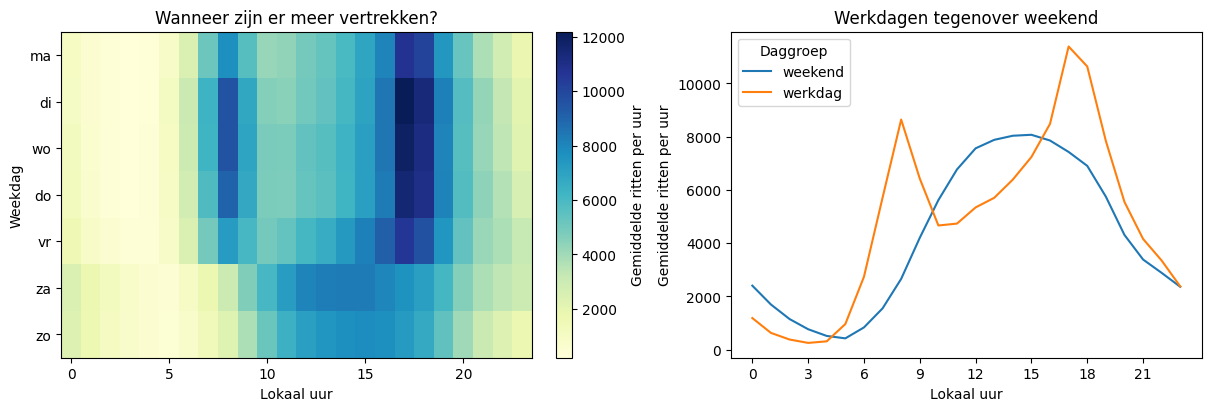

Het gemiddelde uurvolume varieert van 206.0 tot 12,186.0 ritten over de weekdag/uur-combinaties. Dit beschrijft covariatie; de geblokte hypothesetoets onderzoekt een specifiek verschil. Alleen ontwikkeling vanaf 2023 is gebruikt.

In [13]:
show('hour_weekday')

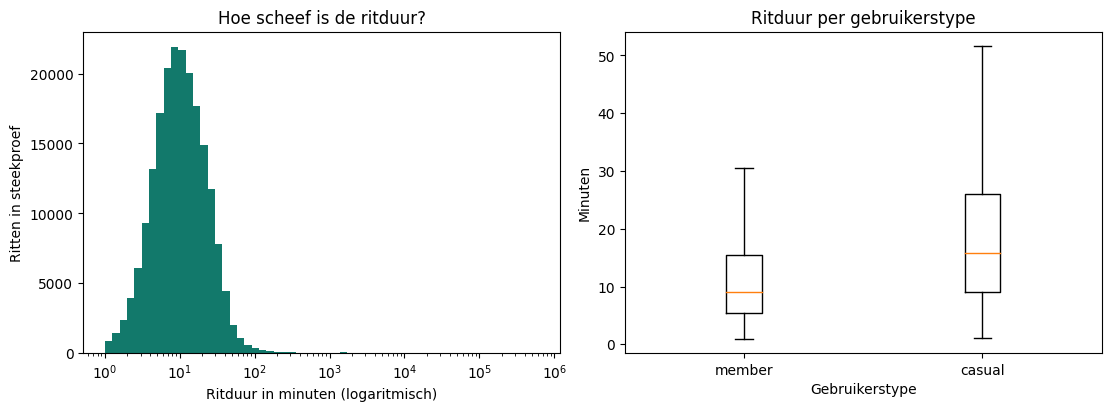

De deterministische steekproef bevat 200,000 ritten. Mediaan: 9.88 minuten; IQR: 11.56 minuten; maximum: 610,844.1 minuten. Boxplot-uitbijters worden alleen verborgen in deze weergave, niet verwijderd uit de data. Exacte groepsaantallen en benaderde volledige-data-kwantielen staan in de aggregatietabellen.

,rides,mean,sd,quantiles,minimum,maximum
0,303478007,18.073241,818.247805,[ 5.76088778 9.90086991 17.28085877 36.364671...,0.016983,1.041872e+06


In [14]:
show('duration')
table('NYC_duration_statistics.csv')

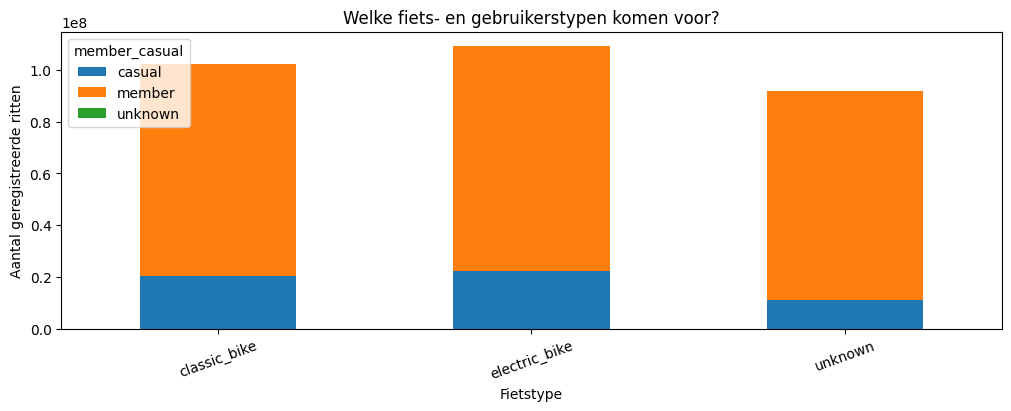

91,944,421 ritten hebben geen bekend fietstype, onder meer door het historische schema. Unknown wordt daarom niet als een echte fietscategorie geïnterpreteerd. Veranderingen in categorieën kunnen zowel gedrag als registratie weerspiegelen.

,member_casual,rideable_type,rides,mean_duration,median_duration
0,member,electric_bike,86921146,12.893676,8.929740
1,member,classic_bike,81848795,15.876694,8.690940
2,member,unknown,80797370,13.364979,9.524468
3,casual,electric_bike,22457891,24.392569,12.724321
4,casual,classic_bike,20326666,51.049436,16.411759
5,casual,unknown,11095271,35.901387,20.727488
6,unknown,unknown,51780,26.740441,20.040322


In [15]:
show('user_bike')
table('NYC_user_bike.csv')

## 7. Aggregaties en geografie

Stations en routes worden vóór visualisatie geaggregeerd. Historische stationnamen kunnen wijzigen. Instroom/uitstroom telt ritten en meet geen actuele voorraad of herbalancering. Een geografisch plotvenster is geen cleaningregel. Jersey City wordt hieronder apart getoond, nooit bij NYC opgeteld.

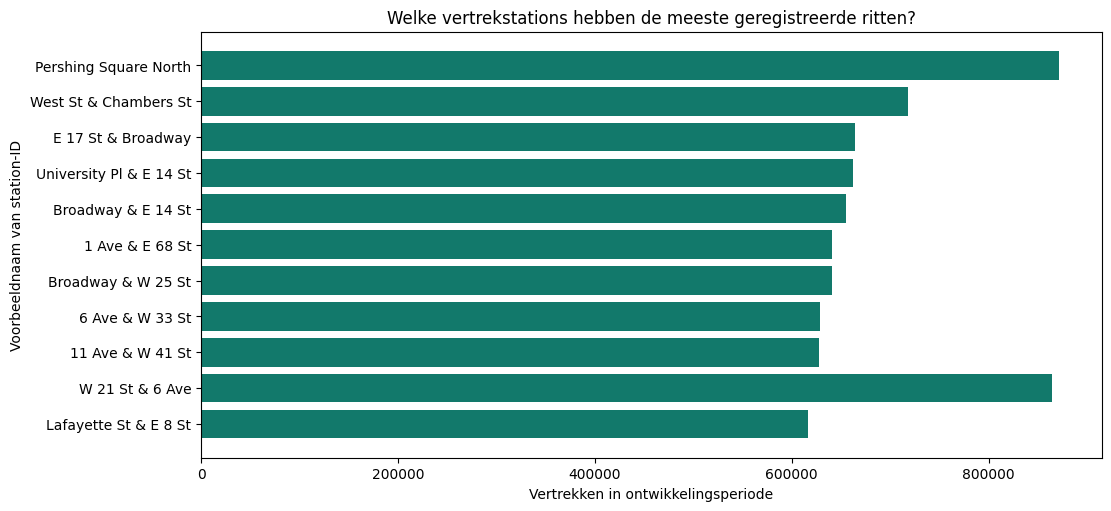

De drukste station-ID in deze aggregatie heeft 871,222 vertrekken en 3 verschillende naamlabels. Dit is een historisch totaal; stations met meer actieve jaren hebben meer gelegenheid om ritten te verzamelen. ID's uit verschillende schema's worden niet zonder bewijs samengevoegd.

In [16]:
show('stations')

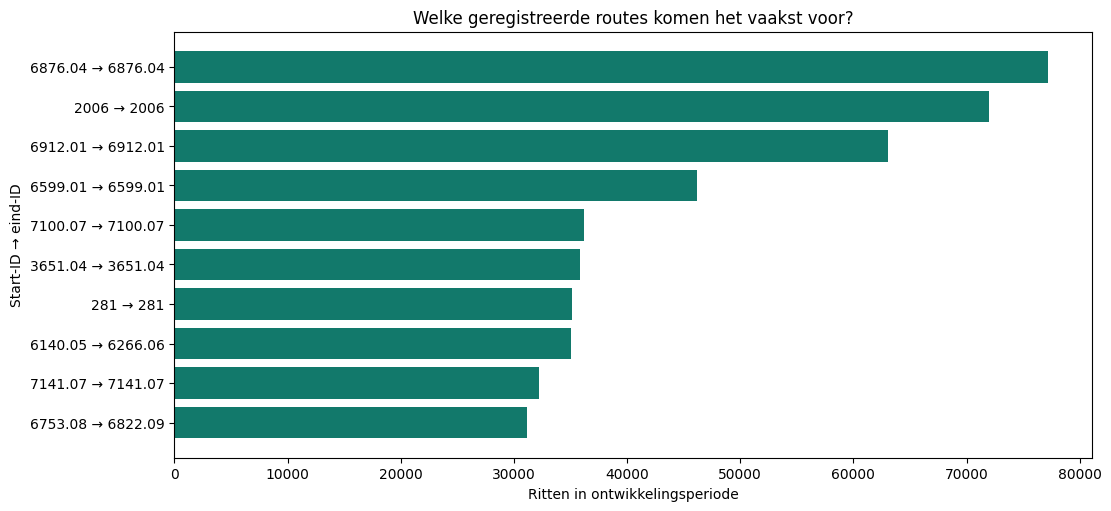

De meest voorkomende geregistreerde route heeft 77,240 ritten. Routevolumes zeggen niets over onvervulde vraag en zijn geen geschikte invoer bij vertrek als de bestemming nog onbekend is.

In [17]:
show('routes')

In [18]:
table('NYC_inflow_outflow.csv')

,station_id,net_inflow
0,5980.1,53955.0
1,5980.10,-53176.0
2,3164,-49913.0
3,324,48489.0
4,5343.1,48042.0
5,5343.10,-47004.0
6,6948.1,-46948.0
7,517,-45340.0
8,6847.02,-43815.0
9,519,-43067.0


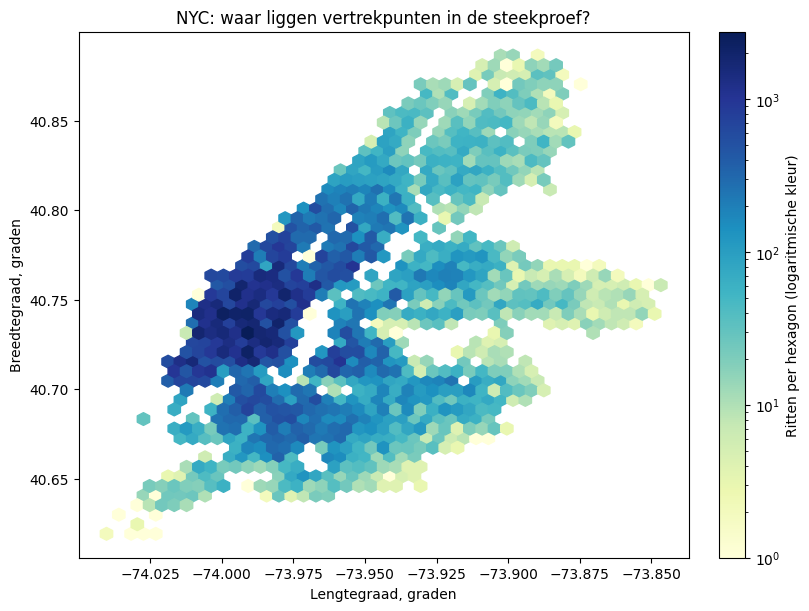

Deze geaggregeerde kaart toont 199,951 steekproefritten binnen het getoonde geografische venster. Buitenliggende punten zijn alleen buiten beeld gehouden. Geldige wereldcoördinaten zijn nog geen bewijs van een betrouwbaar NYC-station.

In [19]:
show('spatial')

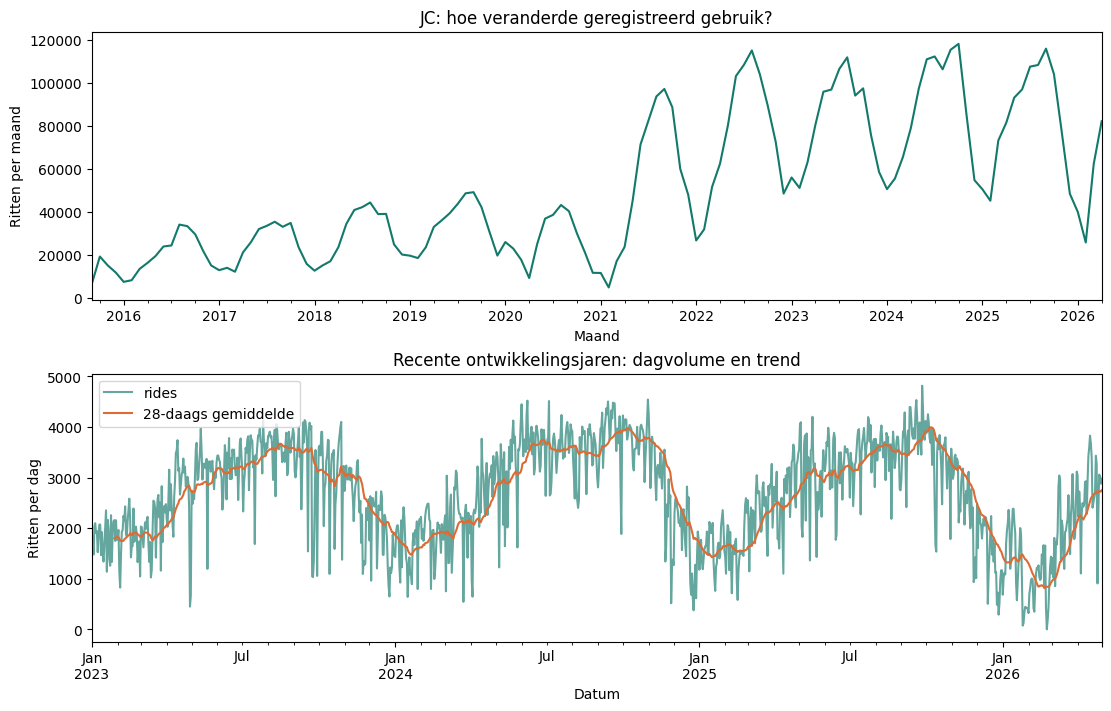

De ontwikkelingsdata bevatten 6,471,987 bruikbare vertrekken. Het recente daggemiddelde is 2,676 ritten en het maximum 4,817. Groei kan samenhangen met systeemuitbreiding; dit bewijst geen oorzaak. De onvolledige eindjaren zijn niet rechtstreeks met volledige jaren vergelijkbaar.

,member_casual,rideable_type,rides,mean_duration,median_duration
0,member,classic_bike,2029727,10.846050,6.036726
1,member,unknown,1483382,10.211774,5.782252
2,member,electric_bike,1337380,8.077066,5.504457
3,casual,classic_bike,676989,24.147659,10.086325
4,casual,electric_bike,596108,17.160070,7.681131
5,casual,unknown,205330,54.367815,19.449396
6,member,docked_bike,77044,14.396426,7.587787
7,casual,docked_bike,65530,82.258247,18.074786
8,unknown,unknown,497,22.216667,14.450000


In [20]:
show('temporal', area='JC')
table('JC_user_bike.csv')

## 8. Statistisch onderzoek

Bij miljoenen ritten kan een klein effect significant zijn. We rapporteren omvang en onzekerheid. Herhaalde tijdspatronen worden onderzocht met ACF; trend en seizoen kunnen correlatie verhogen. Stationariteit is een diagnose, geen verplichte voorwaarde voor iedere regressiemethode.

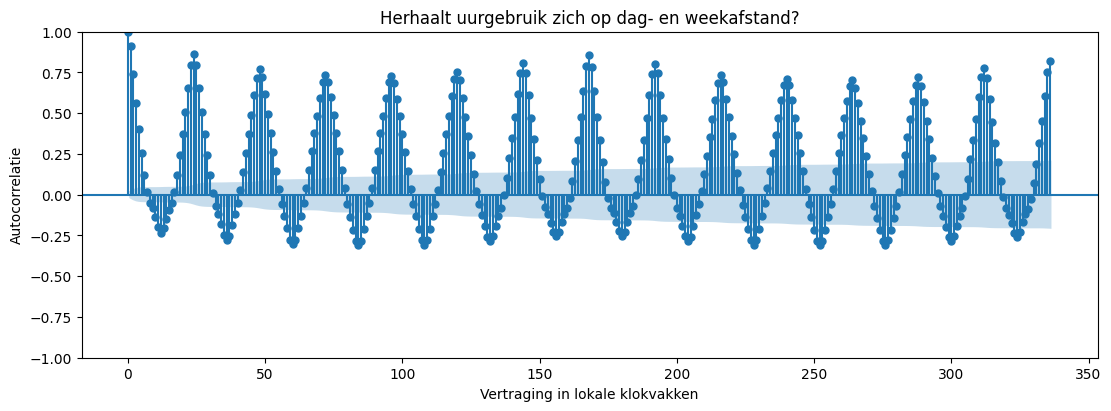

Op deze recente ontwikkelingsperiode is de autocorrelatie bij 24 uur 0.863 en bij 168 uur 0.876. Trend en seizoenen kunnen deze correlaties verhogen; dit is geen zelfstandig bewijs van voorspelprestatie. De latere modellen moeten de baseline op ongeziene perioden verslaan.

,series,ADF_statistic,ADF_p_value,ADF_lags,daily_ACF_1,daily_ACF_7,interpretation
0,"dagtotalen vanaf 2023, uitsluitend ontwikkeling",-2.241588,0.191499,28,0.840841,0.755345,ADF toetst een unit root onder een specifiek m...


In [21]:
show('acf')
if (REPORTS/'time_diagnostics.json').exists():
    display(pd.DataFrame([report('time_diagnostics.json')]))

## 9. Toetsbare hypothesen

De toetsfamilie bestaat uit ochtendrit-aandeel werkdag/weekend, associatie met het vorige weekuur en casual/member-ritduur. De protocolfile is geschreven vóór de berekeningen. Wekelijkse effecten worden in vierweekblokken gegroepeerd; achtweekblokken dienen als sensitiviteitscontrole. Holm-Bonferroni corrigeert de drie toetsen. Sign-flip vereist symmetrie onder H0 en voldoende onafhankelijke blokken.

De vragen zijn geïnformeerd door de EDA: deze toetsen zijn exploratief, geen onafhankelijk bevestigend onderzoek. De 95%-intervallen gelden per hypothese; Holm corrigeert de p-waarden, niet deze intervallen. De latere tijdsvalidatie moet de praktische voorspelwaarde aantonen.

In [22]:
h = report('hypotheses.json')
display(pd.DataFrame([{k:r[k] for k in ['label','H0','H1','statistic','unit','p_value','holm_p_value','ci95','blocks','reject_H0']} for r in h]))
for r in h:
    display(Markdown(f"**{r['label']}**: effect {r['effect_size']:.3f} {r['unit']}; Holm-p {r['holm_p_value']:.6g}. H0 {'verworpen' if r['reject_H0'] else 'niet verworpen'}. Achtweek-sensitiviteit: {r['sensitivity_8weeks']}. Dit is associatie, geen causaliteit."))

,label,H0,H1,statistic,unit,p_value,holm_p_value,ci95,blocks,reject_H0
0,Ochtendrit-aandeel: werkdag minus weekend,Gemiddeld blokeffect is nul,Gemiddeld blokeffect verschilt van nul,9.551946,procentpunt,0.00005,0.00015,"[9.088124610066025, 10.020100731495694]",43,True
1,Associatie van uurtelling met hetzelfde uur vo...,Gemiddeld blokeffect is nul,Gemiddeld blokeffect verschilt van nul,0.856100,Pearson r,0.00005,0.00015,"[0.8365037699140101, 0.8757808290518364]",43,True
2,Dagmediaan ritduur: casual minus member,Gemiddeld blokeffect is nul,Gemiddeld blokeffect verschilt van nul,4.014563,minuten,0.00005,0.00015,"[3.715054931968839, 4.320043804259509]",43,True


**Ochtendrit-aandeel: werkdag minus weekend**: effect 9.552 procentpunt; Holm-p 0.000149993. H0 verworpen. Achtweek-sensitiviteit: {'statistic': 9.489230766012948, 'p_value': 4.999750012499375e-05, 'ci95': [9.033733218693163, 9.966998655109983], 'blocks': 21}. Dit is associatie, geen causaliteit.

**Associatie van uurtelling met hetzelfde uur vorige week**: effect 0.856 Pearson r; Holm-p 0.000149993. H0 verworpen. Achtweek-sensitiviteit: {'statistic': 0.8572124821447673, 'p_value': 4.999750012499375e-05, 'ci95': [0.8320944456541911, 0.8820850833228705], 'blocks': 21}. Dit is associatie, geen causaliteit.

**Dagmediaan ritduur: casual minus member**: effect 4.015 minuten; Holm-p 0.000149993. H0 verworpen. Achtweek-sensitiviteit: {'statistic': 4.031788058230484, 'p_value': 4.999750012499375e-05, 'ci95': [3.6055237738917163, 4.457691442117452], 'blocks': 21}. Dit is associatie, geen causaliteit.

## 10. Voorspelprobleem kiezen

Vóór feature engineering leggen we per kandidaat het voorspeltijdstip en de horizon vast. Groepsverschillen in duur bewijzen geen voorspelbaarheid van individuele ritten. De keuze voor uurvraag vereist een praktisch sterke wekelijkse associatie; validatie moet later aantonen of het model echt helpt.

In [23]:
display(pd.DataFrame(report('prediction_contracts.json')['contracts']))
display(pd.DataFrame(report('target_comparison.json')))
decision = report('target_decision.json')
display(Markdown('**Chosen prediction problem:** ' + decision['chosen_prediction_problem'] + '\n\n' + decision['reason']))

,target,prediction_time,horizon,available,forbidden
0,hourly_demand,00:00 America/New_York op voorspeldag D,alle 24 lokale kloklabels op D (23/25 fysieke ...,kalender van D; gemeten tellingen strikt vóór D,"tellingen eerder op D, weer achteraf, eindstat..."
1,daily_demand,00:00 America/New_York op voorspeldag D,volledig dagtotaal op D,kalender van D; historie strikt vóór D,delen van dagtotaal D; informatie die pas op D...
2,duration,bij vertrek van één rit,duur tot beëindiging van deze rit (geen vaste ...,"starttijd, startstation, bekende gebruiker- en...","eindtijd, eindstation, ritduur; nog niet afger..."


,target,useful,type,target_present,unit,modeling_rows_before_features,leakage_risk,evidence,available_features,deployment,selected,data_quality,limitations
0,hourly_demand,Schat geregistreerd vertrekvolume; geen onverv...,time-series forecasting via regression,True,ritten per klokvak,113208,tellingen op D zijn verboden; alleen volledige...,weekcorrelatie 0.8561; Holm-p 0.000149993,kalender en uitsluitend afgeronde dagen,datum plus 14 volledige historische dagen,True,Aaneengesloten volledige bronmaanden en gevali...,NaN
1,daily_demand,"Dagplanning, minder detail voor piekuren",time-series forecasting via regression,True,ritten per kalenderdag,4717,delen van het huidige dagtotaal mogen niet als...,dagaggregaties en seizoenstrends onderzocht; u...,kalender en voorafgaande dagtotalen,datum plus voorafgaande dagtotalen,False,Dezelfde gevalideerde vertrekken als het uurdo...,NaN
2,duration,Verwachting bij vertrek,regression at departure,True,minuten,303478007,"eindstation, eindtijd en routeafstand achteraf...",casual-member dagmedianenverschil 4.0146 minut...,"startstation, starttijd, bekende categorieën","starttijd, startstation en bekende gebruiker/f...",False,Alleen positieve identificeerbare fysieke duur...,eindbestemming ontbreekt bij vertrek; zware st...


**Chosen prediction problem:** NYC geregistreerde vertrekken per uurvak, dagvooruit om 00:00

Sterke wekelijkse associatie op ontwikkelingsdata plus nuttige uurresolutie; echte voorspelbaarheid volgt uit latere validatie.

## 11. Feature engineering

Het volledige dagprofiel wordt om 00:00 voorspeld. Daarom gebruiken we dezelfde uren op afgeronde voorgaande dagen, niet het vorige uur later op de voorspeldag. Cyclische encodings maken 23:00 en 00:00 naburige uren. Rolling gemiddelden worden eerst één dag verschoven.

### Data Leakage Audit

Eindstation, eindtijd en duur van toekomstige ritten zijn uitgesloten. Historische tellingen zijn pas toegestaan nadat die dag voorbij is.

In [24]:
display(pd.DataFrame(report('leakage_audit.json')))
from citibike.features import make_features, FEATURES
history = pd.read_parquet(DATA/'NYC_hourly_development.parquet')
features = make_features(history)
display(features[['timestamp','rides']+FEATURES].tail(6))

,feature,available_at,available_at_prediction,availability_assumption,target_information,leaks
0,hour_sin,kalender bekend vóór 00:00 op D,True,kalender deterministisch bekend,geen doelwaarden,False
1,hour_cos,kalender bekend vóór 00:00 op D,True,kalender deterministisch bekend,geen doelwaarden,False
2,weekday_sin,kalender bekend vóór 00:00 op D,True,kalender deterministisch bekend,geen doelwaarden,False
3,weekday_cos,kalender bekend vóór 00:00 op D,True,kalender deterministisch bekend,geen doelwaarden,False
4,year_sin,kalender bekend vóór 00:00 op D,True,kalender deterministisch bekend,geen doelwaarden,False
5,year_cos,kalender bekend vóór 00:00 op D,True,kalender deterministisch bekend,geen doelwaarden,False
6,is_weekend,kalender bekend vóór 00:00 op D,True,kalender deterministisch bekend,geen doelwaarden,False
7,clock_hours,kalender bekend vóór 00:00 op D,True,kalender deterministisch bekend,geen doelwaarden,False
8,lag_1d,uitsluitend volledige dagen vóór D; rolling ee...,voorwaardelijk: externe tellingen bekend vóór D,Offline backtest veronderstelt tijdige externe...,historische doelwaarden toegestaan,False
9,lag_2d,uitsluitend volledige dagen vóór D; rolling ee...,voorwaardelijk: externe tellingen bekend vóór D,Offline backtest veronderstelt tijdige externe...,historische doelwaarden toegestaan,False


,timestamp,rides,hour_sin,hour_cos,weekday_sin,weekday_cos,year_sin,year_cos,is_weekend,clock_hours,lag_1d,lag_2d,lag_7d,lag_14d,same_hour_mean_7d,previous_day_total
112866,2026-04-30 18:00:00,14267,-1.000000,-1.836970e-16,0.433884,-0.900969,0.888682,-0.458524,0,1,13780.0,14750.0,17433.0,17956.0,12279.571429,141454.0
112867,2026-04-30 19:00:00,10827,-0.965926,2.588190e-01,0.433884,-0.900969,0.888682,-0.458524,0,1,9591.0,10592.0,12671.0,13308.0,8863.857143,141454.0
112868,2026-04-30 20:00:00,7266,-0.866025,5.000000e-01,0.433884,-0.900969,0.888682,-0.458524,0,1,5100.0,6826.0,8210.0,9441.0,5562.142857,141454.0
112869,2026-04-30 21:00:00,5418,-0.707107,7.071068e-01,0.433884,-0.900969,0.888682,-0.458524,0,1,2645.0,5156.0,6557.0,7253.0,3941.714286,141454.0
112870,2026-04-30 22:00:00,4439,-0.500000,8.660254e-01,0.433884,-0.900969,0.888682,-0.458524,0,1,1449.0,3939.0,5855.0,5865.0,3102.857143,141454.0
112871,2026-04-30 23:00:00,2875,-0.258819,9.659258e-01,0.433884,-0.900969,0.888682,-0.458524,0,1,620.0,2571.0,3667.0,3831.0,2091.142857,141454.0


## 12. Train / validatie / test

Training ligt vóór mei 2026; validatie is mei–juni. De vijf chronologische folds bestaan uit 28 volledige validatiedagen en voorafgaande training. PyCaret gebruikt exact dezelfde opgeslagen indexgrenzen, zonder random CV, shuffling of vooraf geleerde globale preprocessing. Juli–augustus blijft gesloten tot de selectie en het artefact zijn vergrendeld.

In [25]:
split = report('chronological_splits.json')
display(pd.DataFrame(split['folds']))
display(Markdown(f"Train: {split['train_start']} tot {split['train_end_exclusive']} exclusief ({split['train_rows']:,} rijen). Validatie: {split['validation_rows']:,} rijen. Foldfingerprint: `{split['fold_fingerprint']}`."))

,train_start,train_stop,validation_start,validation_stop,train_last_day,validation_first_day,validation_last_day
0,0,109512,109512,110184,2025-12-11,2025-12-12,2026-01-08
1,0,110184,110184,110856,2026-01-08,2026-01-09,2026-02-05
2,0,110856,110856,111528,2026-02-05,2026-02-06,2026-03-05
3,0,111528,111528,112200,2026-03-05,2026-03-06,2026-04-02
4,0,112200,112200,112872,2026-04-02,2026-04-03,2026-04-30


Train: 2013-06-15 00:00:00 tot 2026-05-01 exclusief (112,872 rijen). Validatie: 1,464 rijen. Foldfingerprint: `59238f467d526664e56943f96d102928ede96e4e371fecff4fa382847c7601ad`.

## 13. Baseline en Ridge

De seizoensbaseline neemt hetzelfde lokale uur van de vorige week. Ridge gebruikt een StandardScaler die telkens binnen de trainingsfold wordt gefit. Alle modellen gebruiken dezelfde niet-negatieve voorspellingen en zomertijdregels.

In [26]:
comparison = pd.read_csv(REPORTS/'model_comparison.csv')
display(comparison[comparison.name.isin(['seasonal_naive','ridge'])])

,name,RMSE,MAE,R2,train_RMSE,train_MAE,train_R2,cv_RMSE,fit_cv_seconds
0,seasonal_naive,2826.164920,1510.127732,0.668076,1309.747668,677.011659,0.798089,2086.672928,0.229516
1,ridge,1982.440036,1248.058114,0.836678,1021.691347,578.390365,0.877136,1594.314667,0.866120


## 14. Kandidaatmodellen en AutoML

Random Forest en LightGBM kunnen niet-lineaire interacties leren. We beperken de shortlist tot schaalbare, uitlegbare modellen. PyCaret vergelijkt dezelfde operationele estimators; het bepaalt geen random holdout.

In [27]:
table('pycaret_comparison.csv')
display(pd.DataFrame([report('pycaret_split_audit.json')]).drop(columns='folds'))

,Unnamed: 0,candidate,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
0,3,lightgbm,Light Gradient Boosting Machine,919.4277,2.219320e+06,1433.3589,0.7183,0.8604,1.0487,1.208
1,2,random_forest,Random Forest Regressor,917.6491,2.280610e+06,1460.7833,0.7014,0.8548,1.1461,51.088
2,1,ridge,Ridge Regression,1025.6297,2.668287e+06,1594.3144,0.6369,0.9592,1.1846,0.118
3,0,seasonal_naive,SeasonalNaive,1349.9824,4.550459e+06,2086.6729,0.3707,1.1928,1.2417,0.710


,train_rows,validation_rows,fold_fingerprint,train_data_fingerprint,validation_data_fingerprint,shuffle,preprocess,preprocessing,actual_internal_rows_checked,candidate_labels,operational_prediction_rules
0,112872,1464,59238f467d526664e56943f96d102928ede96e4e371fec...,f5aec178a9fea0223f2d08c98b207909faf272d8a43ff1...,83d6332e2bdba4915e1ee1b4f753468e8fe682bc11feb2...,False,False,Ridge scaler inside per-fold estimator pipeline,True,"[lightgbm, random_forest, ridge, seasonal_naive]",same OperationalRegressor as sklearn and saved...


## 15. Modelvergelijking

RMSE is de hoofdmetriek en blijft in ritten per uur. MAE is de typische absolute fout; R² geeft aanvullende context. Het verschil tussen train en validatie helpt overfit beoordelen.

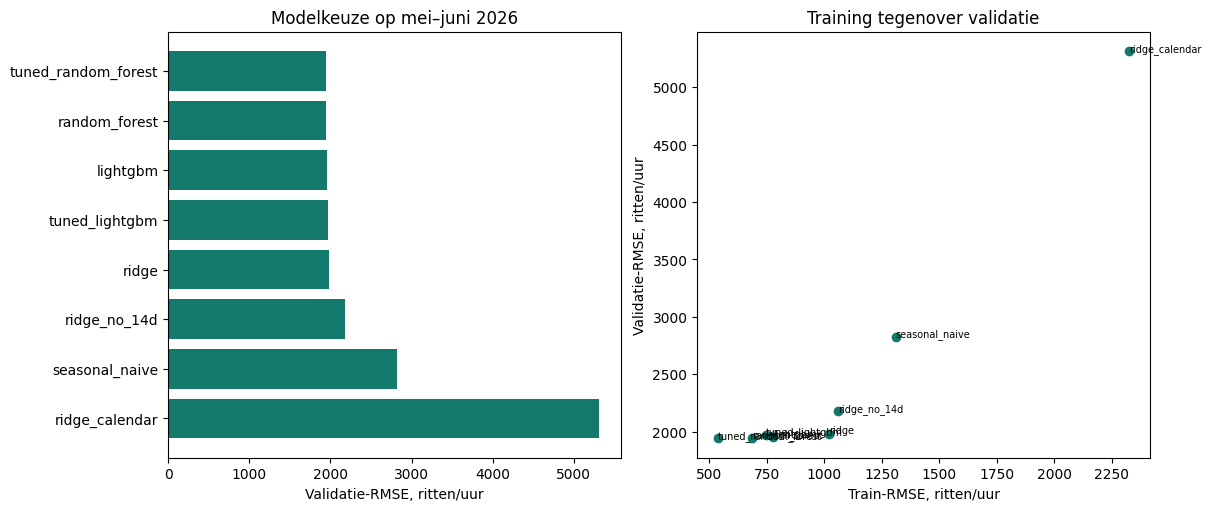

De laagste validatie-RMSE is 1940.49 bij tuned_random_forest; de train-RMSE is 536.13, een verschil van 1404.36 ritten/uur. Een hogere validatiefout kan op overfit of veranderde omstandigheden wijzen. De vastgelegde selectieregel mag binnen 1% het eenvoudigere model kiezen. Een lage trainingsfout alleen rechtvaardigt geen modelkeuze.

,name,RMSE,MAE,R2,train_RMSE,train_MAE,train_R2,cv_RMSE,fit_cv_seconds
0,seasonal_naive,2826.164920,1510.127732,0.668076,1309.747668,677.011659,0.798089,2086.672928,0.229516
1,ridge,1982.440036,1248.058114,0.836678,1021.691347,578.390365,0.877136,1594.314667,0.866120
2,random_forest,1945.709748,1118.646342,0.842674,684.188257,359.153829,0.944902,1460.783347,394.205085
3,lightgbm,1952.244762,1152.417360,0.841616,778.042812,432.043207,0.928749,1423.037130,10.576864
4,tuned_lightgbm,1972.512094,1204.596739,0.838310,744.497812,413.174794,0.934760,1383.390475,8.319329
5,tuned_random_forest,1940.492880,1114.479601,0.843517,536.134489,268.116716,0.966168,1433.759353,811.226580
6,ridge_calendar,5315.257689,3986.439396,-0.174067,2325.245735,1617.036124,0.363611,2590.232107,0.438945
7,ridge_no_14d,2174.787271,1376.786629,0.803448,1060.539908,606.544454,0.867615,1557.951926,0.503810


In [28]:
show('comparison')
table('model_comparison.csv')

## 16. Modelverbetering

Historische trainingsvensters van twee, vijf en alle jaren zijn eerst met trainings-CV vergeleken. De twee sterkste kandidaten krijgen maximaal twintig configuraties. Feature-ablaties onderzoeken kalender-only en het verwijderen van de 14-dagenlag. Geen zoekstap gebruikt de eindtest.

In [29]:
investigation=report('validation_error_investigation.json')
display(pd.DataFrame([{k:v for k,v in investigation.items() if k not in ['hour_MAE','weekday_MAE','largest_errors']}]))
display(pd.DataFrame(investigation['largest_errors']))

,model_before_improvement,mean_bias,worst_hour,worst_hour_MAE,worst_weekday,worst_weekday_MAE,improvement_experiments,test_used
0,random_forest,83.244514,17,2425.475892,5,1820.27889,Tune model capacity; compare calendar-only wit...,False


,timestamp,rides,predicted_rides,residual,absolute_error,hour,weekday,month,season
0,2026-06-14 00:00:00,15757,3820.128249485271,11936.871750514729,11936.871750514729,0,6,6,zomer
1,2026-06-22 18:00:00,5288,16442.79310017197,-11154.79310017197,11154.79310017197,18,0,6,zomer
2,2026-06-22 17:00:00,6059,16996.820207109944,-10937.820207109944,10937.820207109944,17,0,6,zomer
3,2026-05-23 18:00:00,815,11596.922670283533,-10781.922670283533,10781.922670283533,18,5,5,lente
4,2026-05-23 16:00:00,1493,12190.73404590426,-10697.73404590426,10697.73404590426,16,5,5,lente
5,2026-05-23 17:00:00,978,11625.015103972297,-10647.015103972297,10647.015103972297,17,5,5,lente
6,2026-05-23 15:00:00,2176,12549.346997627637,-10373.346997627637,10373.346997627637,15,5,5,lente
7,2026-05-25 08:00:00,1002,10756.967674697536,-9754.967674697536,9754.967674697536,8,0,5,lente
8,2026-05-23 14:00:00,3051,12596.161073513404,-9545.161073513404,9545.161073513404,14,5,5,lente
9,2026-06-22 16:00:00,2177,11688.262915844096,-9511.262915844096,9511.262915844096,16,0,6,zomer


In [30]:
display(pd.DataFrame(report('training_windows.json')).drop(columns='folds'))
for path in sorted(REPORTS.glob('*_tuning.csv')):
    display(Markdown('**'+path.stem+'**'))
    display(pd.read_csv(path)[['configuration','cv_RMSE','parameters']])

,years,model,rows,cv_RMSE
0,2.0,ridge,17520,1576.072219
1,2.0,lightgbm,17520,1504.774563
2,5.0,ridge,43824,1575.824827
3,5.0,lightgbm,43824,1436.839752
4,NaN,ridge,112872,1594.314667
5,NaN,lightgbm,112872,1423.037130


**lightgbm_tuning**

,configuration,cv_RMSE,parameters
0,1,1423.633347,"{""estimator__num_leaves"": 15, ""estimator__n_es..."
1,2,1503.104722,"{""estimator__num_leaves"": 15, ""estimator__n_es..."
2,3,1410.961752,"{""estimator__num_leaves"": 31, ""estimator__n_es..."
3,4,1421.446054,"{""estimator__num_leaves"": 31, ""estimator__n_es..."
4,5,1499.484772,"{""estimator__num_leaves"": 15, ""estimator__n_es..."
5,6,1438.275587,"{""estimator__num_leaves"": 31, ""estimator__n_es..."
6,7,1461.382875,"{""estimator__num_leaves"": 31, ""estimator__n_es..."
7,8,1410.433592,"{""estimator__num_leaves"": 31, ""estimator__n_es..."
8,9,1437.919426,"{""estimator__num_leaves"": 31, ""estimator__n_es..."
9,10,1455.752125,"{""estimator__num_leaves"": 15, ""estimator__n_es..."


**random_forest_tuning**

,configuration,cv_RMSE,parameters
0,1,1485.574606,"{""estimator__n_estimators"": 320, ""estimator__m..."
1,2,1485.152935,"{""estimator__n_estimators"": 240, ""estimator__m..."
2,3,1475.817191,"{""estimator__n_estimators"": 240, ""estimator__m..."
3,4,1433.759353,"{""estimator__n_estimators"": 320, ""estimator__m..."
4,5,1462.581949,"{""estimator__n_estimators"": 320, ""estimator__m..."
5,6,1459.088472,"{""estimator__n_estimators"": 240, ""estimator__m..."


In [31]:
display(pd.DataFrame([report('tuning_protocol.json')]))

,created_at,models,configurations,seed,fold_fingerprint,test_used,reason
0,2026-10-09T10:46:52.600937+00:00,"[lightgbm, random_forest]","{'lightgbm': 20, 'random_forest': 6}",42,59238f467d526664e56943f96d102928ede96e4e371fec...,False,Resource budget fixed before tuning: Random Fo...


## 17. Validatiefouten en residuen

Residueel = werkelijk − voorspeld. Systematische patronen tonen wat nog niet gevangen is. De ablaties zijn ontwikkelingsvergelijkingen; ze geven geen recht om na de eindtest verder te tunen.

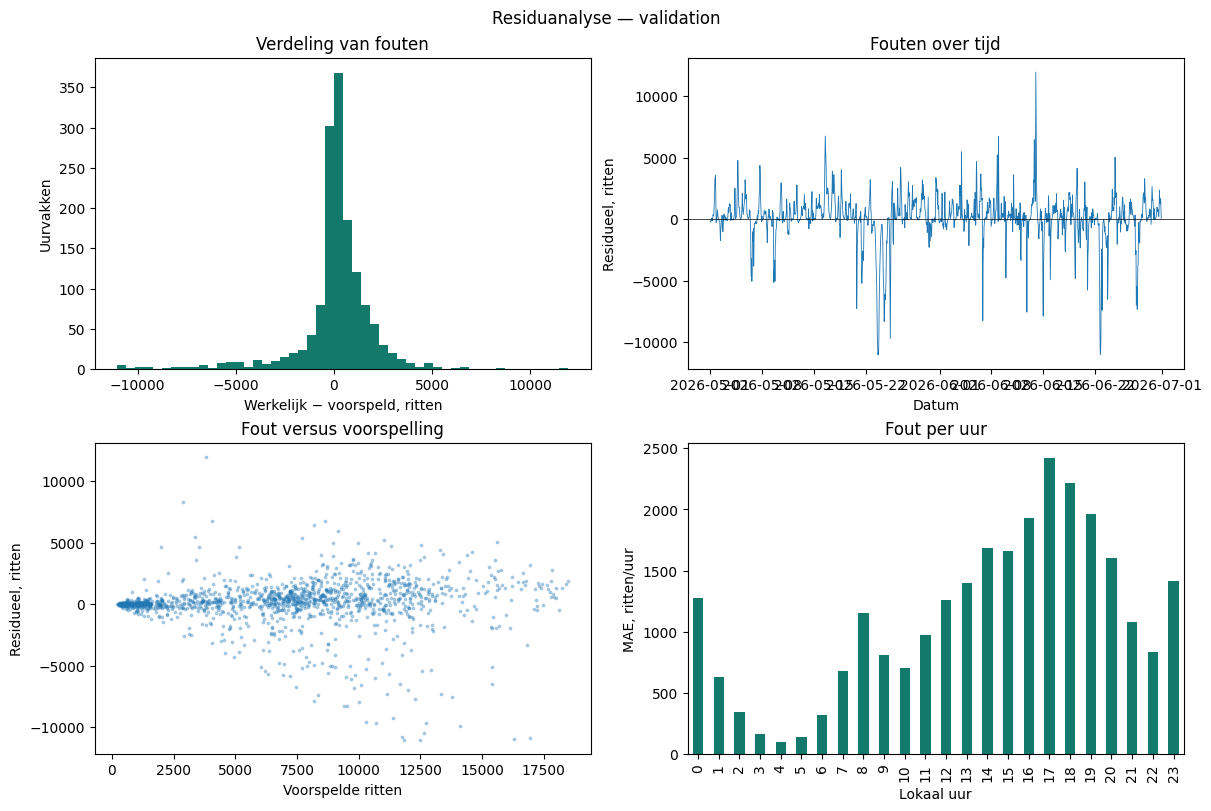

Gemiddelde bias: 105.00 ritten/uur. Het uur met de hoogste MAE is 17:00 (2422.61 ritten/uur). Overblijvende patronen wijzen op beperkingen. Eindtestdiagnostiek wordt uitsluitend achteraf beschreven en leidt niet tot nieuwe tuning onder dezelfde eindtestclaim.

,weekday,MAE,bias,n
0,0,1249.698235,-46.354453,216
1,1,837.733136,398.650639,216
2,2,905.994113,228.853450,192
3,3,832.448689,223.062460,192
4,4,859.539685,304.258624,216
5,5,1793.238662,-505.899364,216
6,6,1268.202864,159.282670,216


,season,MAE,bias,n
0,lente,1159.356232,103.492985,744
1,zomer,1068.107082,106.549592,720


In [32]:
show('residual_validation')
table('validation_errors_by_weekday.csv')
table('validation_errors_by_season.csv')

## 18. Definitieve selectie en eenmalige eindtest

De kleinste validatie-RMSE wint; binnen 1% kiezen we het eenvoudigere model. Daarna wordt opnieuw gefit op geschikte data tot eind juni. Het vaste model voorspelt iedere testdag met alleen op dat moment bekende historie. Testdiagnostiek is uitsluitend een eindrapport.

De vooraf vastgelegde eenvoudigheidsrang betreft modeltypen: weekbaseline → Ridge → Random Forest → LightGBM. Binnen dezelfde familie kiest de laagste validatie-RMSE. Het aantal bomen en de diepte krijgen geen afzonderlijke complexiteitsrang. De RF-tuning levert slechts circa 0,27% extra validatiewinst tegenover de oorspronkelijke RF; het grotere uiteindelijke artefact is circa 647 MiB. Die praktische kosten moeten naast de score worden beoordeeld.

In [33]:
selection = report('model_selection.json')
final = report('final_evaluation.json')
display(pd.DataFrame([{'model':final['selected_model'],**final['metrics']},{'model':'seasonal_naive',**final['baseline_metrics']}]))
display(Markdown(f"Eindtest-RMSE-verbetering: **{final['RMSE_improvement_percent']:.2f}%**. MSE-verschil, weekbootstrap-95%-CI: {final['MSE_gain_week_bootstrap_ci95']}. {final['ci_limitation']}"))

,model,RMSE,MAE,R2
0,tuned_random_forest,1979.507160,1076.225847,0.828015
1,seasonal_naive,2608.777506,1453.528226,0.701289


Eindtest-RMSE-verbetering: **24.12%**. MSE-verschil, weekbootstrap-95%-CI: [1161795.8570921829, 4198151.224649241]. Slechts circa negen weekblokken; onzekerheidsinterval is indicatief en veronderstelt beperkte afhankelijkheid.

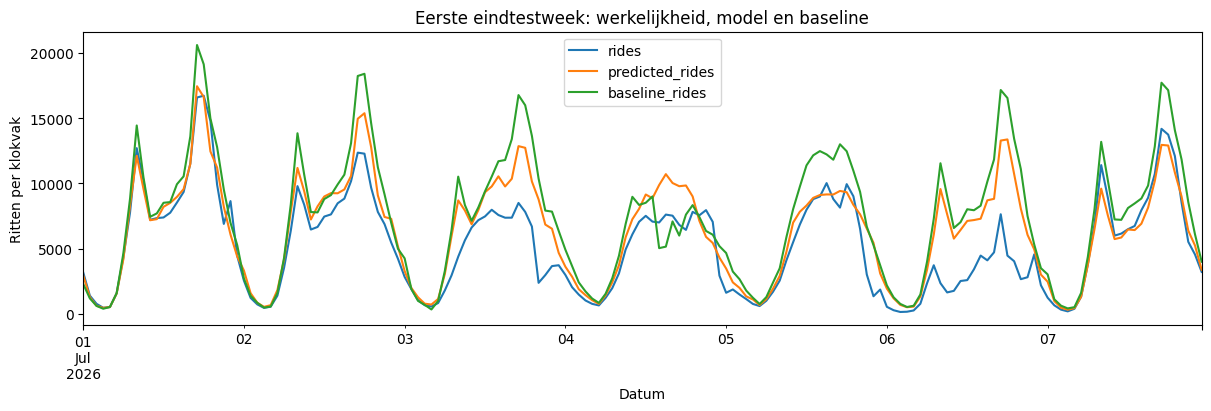

Over de volledige eindtest is de model-RMSE 1979.51, tegenover 2608.78 voor het vorige weekuur. Verbetering: 24.12%. Iedere dag gebruikt alleen eerder gemeten dagen.

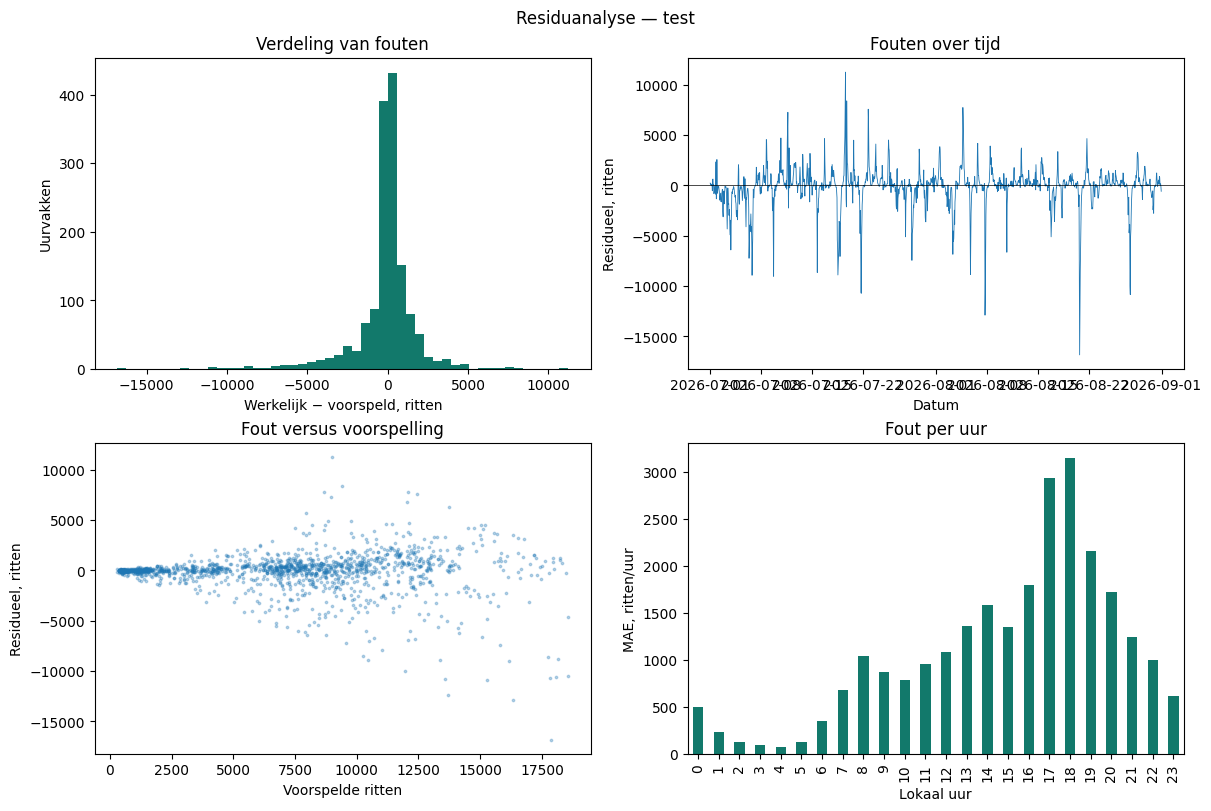

Gemiddelde bias: -127.60 ritten/uur. Het uur met de hoogste MAE is 18:00 (3147.24 ritten/uur). Overblijvende patronen wijzen op beperkingen. Eindtestdiagnostiek wordt uitsluitend achteraf beschreven en leidt niet tot nieuwe tuning onder dezelfde eindtestclaim.

In [34]:
show('test_forecast')
show('residual_test')

## 19. Interpretatie — INTERPRET

Permutation importance wordt op validatie berekend. Correlatie tussen features en onrealistische permutaties beperken de interpretatie. Weer, capaciteit en evenementen ontbreken; geen feature importance bewijst causaliteit.

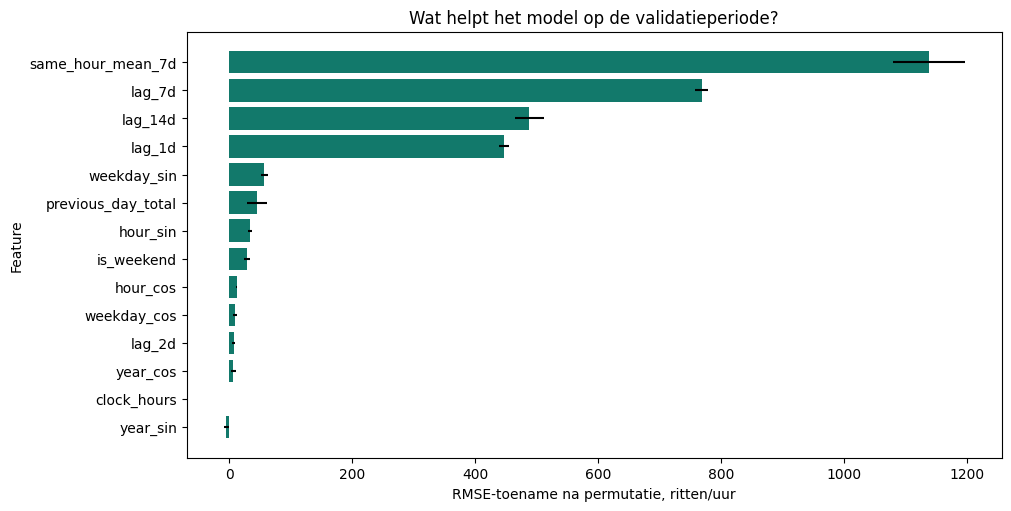

De sterkste gemeten permutation importance hoort bij same_hour_mean_7d: 1137.75 ritten/uur RMSE-toename. Afhankelijke features kunnen elkaars belang maskeren; onafhankelijke permutatie kan onrealistische combinaties maken. Dit toont geen causaliteit.

In [35]:
show('importance')

## 20. Deployment — DEPLOY

De lokale Streamlit-app laadt het opgeslagen artefact zonder training. De gedeelde voorspelfunctie controleert NYC, volledige historie, tijdzoneconventie en afwezigheid van toekomstige tellingen. Het historische voorbeeld hieronder is een functiedemonstratie op ontwikkeling, geen onafhankelijke prestatietest.

In [36]:
from citibike.inference import predict_day
day = history.timestamp.max().normalize()
prediction = predict_day(day, history[history.timestamp < day])
display(prediction)

,timestamp,clock_hours,predicted_rides
0,2026-04-30 00:00:00,1,1094.383420
1,2026-04-30 01:00:00,1,561.665549
2,2026-04-30 02:00:00,1,341.733590
3,2026-04-30 03:00:00,1,253.783953
4,2026-04-30 04:00:00,1,334.219510
5,2026-04-30 05:00:00,1,1055.889292
6,2026-04-30 06:00:00,1,3158.959519
7,2026-04-30 07:00:00,1,7574.195047
8,2026-04-30 08:00:00,1,11860.514053
9,2026-04-30 09:00:00,1,8874.899801


## 21. Conclusies, beperkingen en reproduceerbaarheid

Alle getallen komen uit uitvoer. Het model voorspelt geregistreerd gebruik, geen onvervulde vraag. Twee zomermaanden testen geen volledige toekomstige seizoenscyclus. Schema’s, stations en systeemgebruik veranderen. AWS-training is nog een afzonderlijke schoolopdracht. Het model staat lokaal buiten Git; bronmanifest, scripts, dependencies en seeds maken hertraining mogelijk.

In [37]:
display(Markdown((REPORTS/'MODEL_CARD.md').read_text(encoding='utf-8')))
verification = report('verification.json')
display(pd.DataFrame([verification]))
display(pd.DataFrame([report('test_results.json')]).drop(columns='test_names'))

# Citi Bike-modelkaart

Gekozen model: **tuned_random_forest**. Het voorspelt geregistreerde NYC-vertrekken
per lokaal uurvak, voor één volledige kalenderdag vanaf 00:00 New York-tijd.
Veertien volledige voorafgaande dagen zijn nodig. Jersey City is uitgesloten.

| Metriek | Eindmodel | Vorig weekuur |
|---|---:|---:|
| RMSE, ritten/uur | 1979.51 | 2608.78 |
| MAE, ritten/uur | 1076.23 | 1453.53 |
| R² | 0.8280 | 0.7013 |

RMSE-verbetering: 24.12%. Eindtest juli–augustus 2026,
1488 klokvakken. Selectie en tuning gebruikten deze uitkomsten niet.
Het model blijft vast; eerder gemeten testdagen worden daarna historische invoer.
Het artefact is na de eindtest niet opnieuw getraind.

Dit is geregistreerd gebruik, geen onvervulde vraag of beschikbaarheid per station.
Weer, evenementen en capaciteit ontbreken. Feature importance toont geen causaliteit.
Historische schema's en gebruik veranderen; twee testmaanden dekken niet alle seizoenen.
Het weekbootstrapinterval bevat weinig blokken en geeft beperkte zekerheid.
De actuele maandarchieven leveren niet automatisch de recente historie voor morgen.
De backtest veronderstelt een externe bron met vóór 00:00 beschikbare uurtellingen.
Publicatie-, ingestie- en rekenlatentie zijn niet gemodelleerd. De prestaties gelden
onder dit invoercontract; een operationele tellingenfeed moet apart worden gerealiseerd.

Hertrain offline met de README-commando's. Modelbestanden staan lokaal en buiten Git.
Bronnen, code, packageversies, seeds, splits en fingerprints zijn vastgelegd.
AWS-training blijft open voor de volledige schoolopdracht.


,python_version,python_executable,partitions_verified,manifest_fingerprint_verified,pycaret_identical_folds,offline_app_predictions_equal,pycaret_identical_train_validation_rows,fixed_configuration_retraining_verified,retraining_seconds,retraining_prediction_max_difference,streamlit_form_predictions_verified,manifest_required_fields_verified,model_ignored_by_git,evaluated_model_is_deployed,prediction_code_and_packages_locked,raw_rows,retained_rows,modeling_rows,test_rows
0,"3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.19...",C:\Deeplearning\CloudAI\Citybike_full\.venv\Sc...,291,True,True,True,True,True,98.911651,3.637979e-12,True,True,True,True,True,355199439,330714664,114336,1488


,executed_at,command,tests,passed,failed,skipped,code_version
0,2026-10-09T11:16:25.515136+00:00,.venv/Scripts/python.exe -X utf8 tools/run_tes...,27,27,0,0,{'fingerprint': 'e14bcf107b80d81e45c0261762c47...
